# Section 1: Dataset Description

In [1]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets/winemag-data-130k-v2.csv', index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


# Section 2: Data Preprocessing and EDA

## 2.1: Handling Missing Values

### Desribe()

In [2]:
df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


In [3]:
df.describe(include = 'all')

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,129908,129971,92506,129971.000000,120975.000000,129908,108724,50511,103727,98758,129971,129970,129971
unique,43,119955,37979,NaN,NaN,425,1229,17,19,15,118840,707,16757
top,US,"Gravenstein apple, honeysuckle and jasmine aro...",Reserve,NaN,NaN,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,54504,3,2009,NaN,NaN,36247,4480,11065,25514,25514,11,13272,222
mean,NaN,NaN,NaN,88.447138,35.363389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,3.039730,41.022218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,86.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,88.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,91.000000,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### isnull() checking

In [4]:
# Check missing counts per column
print(df.isnull().sum())

country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


### Data Visualizations For Missing Values using Histograms and Calculating Feature Importance

By seeing how the missing values and how much they are important for predicting the target 'points', we will handle their missing values.

/tmp/ipykernel_6476/1308822625.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


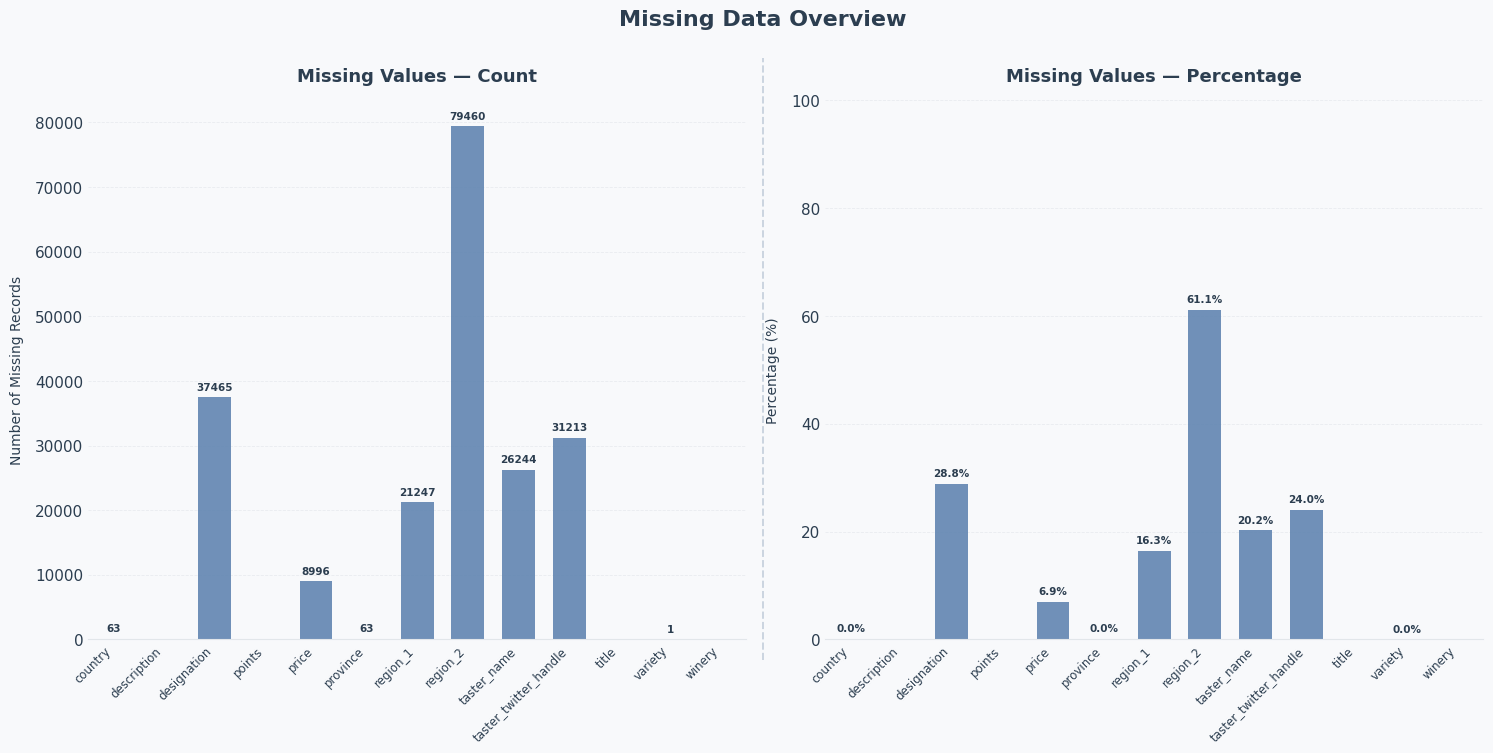

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# ── Palette & style ──────────────────────────────────────────────────────────
ACCENT   = "#4F81BD"
BG       = "#F8F9FB"
GRID     = "#E2E6EA"
TEXT     = "#2C3E50"
DIVIDER  = "#CBD5E0"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.facecolor":   BG,
    "figure.facecolor": BG,
    "axes.edgecolor":   GRID,
    "axes.linewidth":   0.8,
    "grid.color":       GRID,
    "grid.linewidth":   0.6,
    "text.color":       TEXT,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
})

# ── Data ─────────────────────────────────────────────────────────────────────
missing_counts      = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    gridspec_kw={"wspace": 0.12},   # tight gap — divider line fills it
)
fig.patch.set_facecolor(BG)

# ── Helper to draw one bar chart ─────────────────────────────────────────────
def styled_bar(ax, y_data, title, ylabel, ylim=None):
    bars = sns.barplot(
        x=list(df.columns), y=y_data,
        ax=ax, color=ACCENT,
        width=0.65, linewidth=0,
    )
    # Gradient-like alpha: slightly lighter for short bars
    for bar in bars.patches:
        bar.set_alpha(0.88)

    # Value labels on top of each bar
    for bar, val in zip(bars.patches, y_data):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (ylim[1] * 0.01 if ylim else max(y_data) * 0.01),
                f"{val:.0f}" if ylabel.startswith("Number") else f"{val:.1f}%",
                ha="center", va="bottom", fontsize=7.5, color=TEXT, fontweight="bold",
            )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=14, color=TEXT)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=8)
    ax.set_xlabel("")
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha="right", fontsize=8.5)
    ax.tick_params(axis="both", length=0)          # hide tick marks
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    if ylim:
        ax.set_ylim(*ylim)

styled_bar(axes[0], missing_counts,      "Missing Values — Count",      "Number of Missing Records")
styled_bar(axes[1], missing_percentages, "Missing Values — Percentage", "Percentage (%)", ylim=(0, 100))

# ── Vertical divider line (figure coordinates) ───────────────────────────────
fig.add_artist(
    mlines.Line2D(
        [0.5, 0.5], [0.08, 0.94],          # x stays at figure midpoint; y trims top/bottom
        transform=fig.transFigure,
        color=DIVIDER, linewidth=1.4, linestyle="--",
    )
)

# ── Shared super-title ───────────────────────────────────────────────────────
fig.suptitle("Missing Data Overview", fontsize=16, fontweight="bold",
             color=TEXT, y=1.01)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6476/3201016309.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


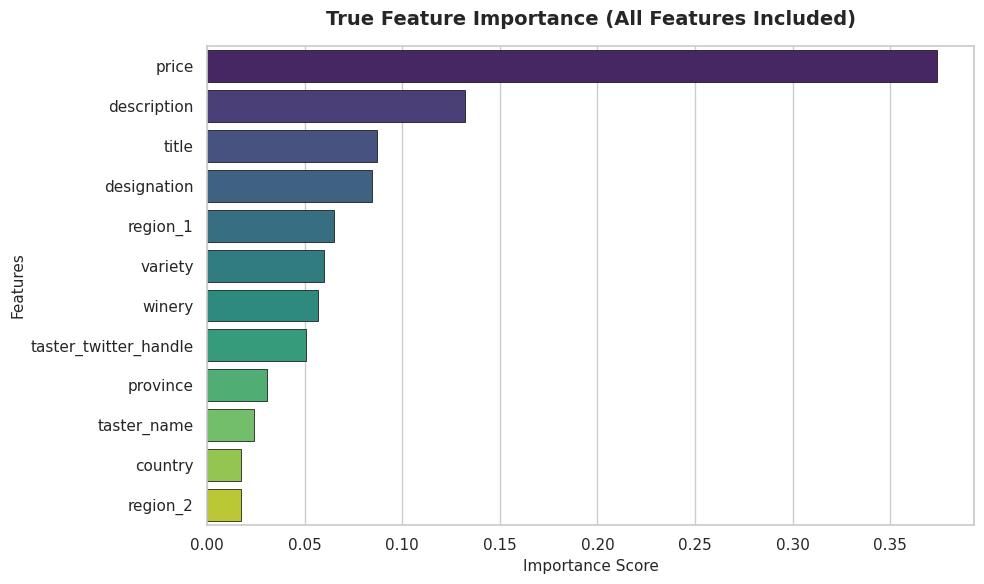

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make a quick test copy
df_test = df.copy()

# 2. Safely fill text and numeric columns temporarily so the model doesn't crash
for col in df_test.columns:
    if df_test[col].dtype == 'object':
        df_test[col] = df_test[col].fillna('Unknown').astype('category').cat.codes
    else:
        df_test[col] = df_test[col].fillna(-999)

# 3. Separate features and target (points)
X_test = df_test.drop(columns=['points'])
y_test = df_test['points']

# 4. Run a fast Random Forest
rf_test = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_test.fit(X_test, y_test)

# 5. Get the scores
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': rf_test.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 6. Plot the results beautifully
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis',
    edgecolor="black",
    linewidth=0.5
)
plt.title("True Feature Importance (All Features Included)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.tight_layout()
plt.show()

### Handling Missing Values Based On their Quantity Of Missing and Their Importance

As these two columns having missing values of [ 20.2% ] and [ 61.1% ] of the whole dataset, at the same time, their Feature Importance is not even 0.05, so, we will permanenly DROP them from our main DataFrame.

In [7]:
df = df.drop(columns=['region_2', 'taster_name'])
print(df.columns)

Index(['country', 'description', 'designation', 'points', 'price', 'province',
       'region_1', 'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='object')


[country = 63] [province = 63] [variety = 1] missing values and their feature importance is also not that much, so, i will drop them but this one is not like dropping the whole columns, but dropping the rows that have the missing values under those columns.

In [8]:
df = df.dropna(subset=['country', 'province', 'variety'])
print(df[['country', 'province', 'variety']].isnull().sum())
print(f"Remaining records in dataset: {len(df)}")

country     0
province    0
variety     0
dtype: int64
Remaining records in dataset: 129907


In [9]:
print(df.isnull().sum())

country                      0
description                  0
designation              37453
points                       0
price                     8992
province                     0
region_1                 21183
taster_twitter_handle    31212
title                        0
variety                      0
winery                       0
dtype: int64


As these three are the three largest columns of missing values counts as well as their importance is quite high, I have to fill them 'Unknown', which is the one used in FEATURE IMPORTANCE CALCULATION.

In [10]:
text_cols = ['designation', 'region_1', 'taster_twitter_handle']
df[text_cols] = df[text_cols].fillna('Unknown')

As price is the most IMPORATNT column for target [points], and it is also missing 6.9%, dropping the rows with missing prices is better than creating fake relationships.

In [11]:
df = df.dropna(subset=['price'])

In [12]:

print(df.isnull().sum())
print(f"\nFinal dataset size for training: {len(df)} records")

country                  0
description              0
designation              0
points                   0
price                    0
province                 0
region_1                 0
taster_twitter_handle    0
title                    0
variety                  0
winery                   0
dtype: int64

Final dataset size for training: 120915 records


## 2.2: Detecting Outliers For Numerical Features

In Outlier Box Plot Graph, numbers are visualized with [ min, 25%, 50%, 75%, Outlier-Capped and 100% ] meaning that, Outlier-Capped and 100% value should not be very far away.

In other word, if you see the 'points' box plot, outlier-capped is at around 97.5 and max is 100, not much difference, so, no need to do anything.

But for 'price' box plot, 75% is just 42 exactly, and outliers is capped around 80, but haha max is 3300, so, box plot rises infinitely and those values over 80 are real problems, because, the model will recognize these next-level prices where learning and will create bias.

Even If you look the data distrubution graph in second cell, you will see that, the price graph is right-skewed, meaning that most of the samples have prices below 100.

But, we do not handle this right now, because, we will use Predefined Function for both of our models to do [ Encoding, Feature Scaling and Train Test Splits ]. So, we will define this at there, by using nlogp() which is an ideal scaler for this massive outliers in price.

 EXACT BOX PLOT DETAILS & OUTLIER COUNTS (CURRENT DATASET) 
WINE POINTS STATUS:
  - 25th Percentile (Q1) : 86.0 points
  - 75th Percentile (Q3) : 91.0 points
  - Lower Whisker Bound  : 78.5 points
  - Upper Whisker Bound  : 98.5 points
  - EXACT OUTLIER COUNT  : 47 records (Wines rated 99 and 100 points)
  - Outlier Scores Found : [np.int64(99), np.int64(100)]
------------------------------------------------------------
WINE PRICE STATUS:
  - 25th Percentile (Q1) : $17.00
  - 75th Percentile (Q3) : $42.00
  - Lower Whisker Bound  : $-20.50 (Treated as $0)
  - Upper Whisker Bound  : $79.50
  - EXACT OUTLIER COUNT  : 7,241 records (Wines > $79.50)
  - Maximum Outlier Price: $3300.00


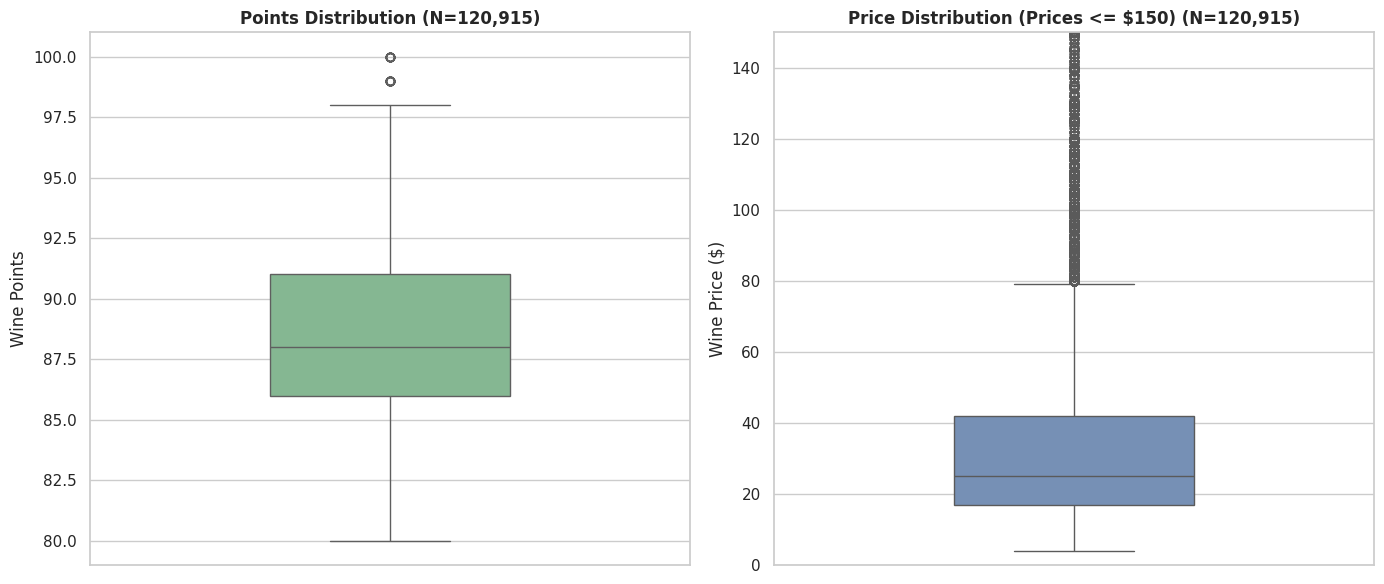

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CALCULATION OF EXACT OUTLIER DETAILS (IQR Method used by Box Plots)
# =====================================================================

def get_outlier_details(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    # Calculate box plot whisker thresholds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count outliers
    outliers_below = series[series < lower_bound]
    outliers_above = series[series > upper_bound]
    total_outliers = len(outliers_below) + len(outliers_above)

    return q1, q3, lower_bound, upper_bound, total_outliers, outliers_above

# Get details directly from your evolved 'df'
p_q1, p_q3, p_low, p_high, p_total, p_outliers = get_outlier_details(df['points'])
pr_q1, pr_q3, pr_low, pr_high, pr_total, pr_outliers = get_outlier_details(df['price'])

# Print the precise breakdown report
print("="*60)
print(" EXACT BOX PLOT DETAILS & OUTLIER COUNTS (CURRENT DATASET) ")
print("="*60)
print(f"WINE POINTS STATUS:")
print(f"  - 25th Percentile (Q1) : {p_q1} points")
print(f"  - 75th Percentile (Q3) : {p_q3} points")
print(f"  - Lower Whisker Bound  : {p_low} points")
print(f"  - Upper Whisker Bound  : {p_high} points")
print(f"  - EXACT OUTLIER COUNT  : {p_total} records (Wines rated 99 and 100 points)")
print(f"  - Outlier Scores Found : {sorted(p_outliers.unique())}")
print("-"*60)
print(f"WINE PRICE STATUS:")
print(f"  - 25th Percentile (Q1) : ${pr_q1:.2f}")
print(f"  - 75th Percentile (Q3) : ${pr_q3:.2f}")
print(f"  - Lower Whisker Bound  : ${pr_low:.2f} (Treated as $0)")
print(f"  - Upper Whisker Bound  : ${pr_high:.2f}")
print(f"  - EXACT OUTLIER COUNT  : {pr_total:,} records (Wines > ${pr_high:.2f})")
print(f"  - Maximum Outlier Price: ${df['price'].max():.2f}")
print("="*60)


# =====================================================================
# VISUALIZATION (Single Dataset)
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left Box Plot: Points
sns.boxplot(
    y='points', data=df,
    ax=axes[0], color='#7DBF8E', width=0.4
)
axes[0].set_title(f'Points Distribution (N={len(df):,})', fontsize=12, weight='bold')
axes[0].set_ylabel('Wine Points')

# Right Box Plot: Price
sns.boxplot(
    y='price', data=df,
    ax=axes[1], color='#6C8EBF', width=0.4
)
axes[1].set_ylim(0, 150)
axes[1].set_title(f'Price Distribution (Prices <= $150) (N={len(df):,})', fontsize=12, weight='bold')
axes[1].set_ylabel('Wine Price ($)')

plt.tight_layout()
plt.show()

In [14]:
df.describe()

,points,price
count,120915.000000,120915.000000
mean,88.421726,35.368796
std,3.044954,41.031188
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


## 2.3: Checking Data Distribution
Data Distribution on Points is Symmetric, therefore, can let the outliers live. But for Price, it is positively skewed, right-skewed, so, Extreme Outliers must be handled.

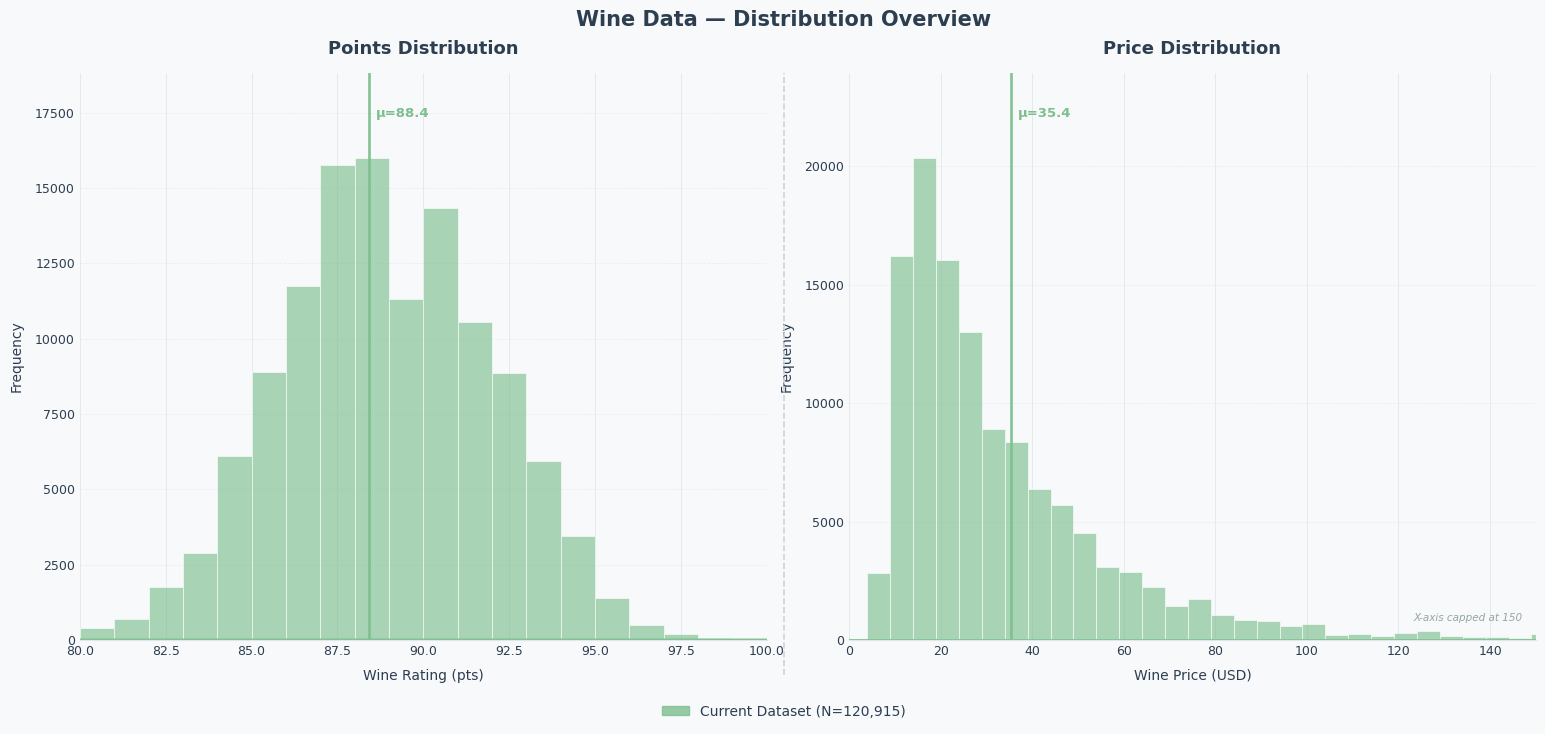

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

# ── Palette ───────────────────────────────────────────────────────────────────
BG      = "#F8F9FB"
TEXT    = "#2C3E50"
GRID    = "#E2E6EA"
DIVIDER = "#CBD5E0"
C_MAIN  = "#7DBF8E"  # Using that clean green for your main charts

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.facecolor":   BG,
    "figure.facecolor": BG,
    "axes.edgecolor":   GRID,
    "axes.linewidth":   0.8,
    "grid.color":       GRID,
    "grid.linewidth":   0.6,
    "text.color":       TEXT,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
})

# ── Helper ────────────────────────────────────────────────────────────────────
def styled_histogram(ax, col, title, xlabel, xlim, binwidth):
    # Pulling directly from your evolved df
    data = df[col].dropna()

    # Histogram
    sns.histplot(data, ax=ax, binwidth=binwidth,
                 color=C_MAIN, alpha=0.65, edgecolor='white', linewidth=0.4)

    # Fix xlim BEFORE KDE
    ax.set_xlim(*xlim)

    # KDE — clipped to xlim
    sns.kdeplot(data, ax=ax, color=C_MAIN, linewidth=2,
                bw_adjust=1.2, clip=xlim)

    # Fix ylim NOW (after all draws) before adding text
    ax.autoscale(axis='y')
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.12)   # 12% headroom for labels

    # Mean line + label
    mu = data.mean()
    ax.axvline(mu, color=C_MAIN, linestyle='-', linewidth=2, alpha=0.9)
    ax.text(mu + (xlim[1] - xlim[0]) * 0.01,
            ax.get_ylim()[1] * 0.94,
            f'μ={mu:.1f}',
            color=C_MAIN, fontsize=9.5, va='top', fontweight='bold')

    # Styling
    ax.set_title(title,  fontsize=13, fontweight='bold', pad=14, color=TEXT)
    ax.set_xlabel(xlabel, fontsize=10, labelpad=8)
    ax.set_ylabel('Frequency', fontsize=10, labelpad=8)
    ax.tick_params(axis='both', length=0, labelsize=9)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)

    if xlim[1] < df[col].max():
        ax.annotate(f'X-axis capped at {xlim[1]}',
                    xy=(0.98, 0.03), xycoords='axes fraction',
                    ha='right', va='bottom', fontsize=7.5,
                    color='#95A5A6', style='italic')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={"wspace": 0.12})

styled_histogram(axes[0], 'points', 'Points Distribution',
                 'Wine Rating (pts)', xlim=(80, 100), binwidth=1)

styled_histogram(axes[1], 'price',  'Price Distribution',
                 'Wine Price (USD)',  xlim=(0, 150),   binwidth=5)

# ── Vertical divider ──────────────────────────────────────────────────────────
fig.add_artist(
    mlines.Line2D(
        [0.5, 0.5], [0.07, 0.93],
        transform=fig.transFigure,
        color=DIVIDER, linewidth=1.2, linestyle='--',
    )
)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color=C_MAIN, alpha=0.80, label=f'Current Dataset (N={len(df):,})'),
]
fig.legend(handles=handles, loc='lower center', ncol=1,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Wine Data — Distribution Overview',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)

fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.12)  # replaces tight_layout
plt.show()

### Comparing the price distribution before and after using np.log1p().
But take note that, we are using temporary variables such as raw_price, temp_log_price like that, because, the real implemenation of log1p() will be used only in predefined preprocessor() function blogs for both models.

This one is just for Data Visualization on how price is handled and the distrubution changes.

  📊 NUMBER RANGE & SKEWNESS COMPARISON (Before vs After)
  🔹 RAW PRICE RANGE      : $4.00  to  $3,300.00
  🔹 LOG1P PRICE RANGE    : 1.6094  to  8.1020
-----------------------------------------------------------------
  💥 Raw Price Skewness   : 17.9977  (Highly Skewed Tail)
  🎯 Log1p Price Skewness : 0.6569   (Balanced Bell Curve)


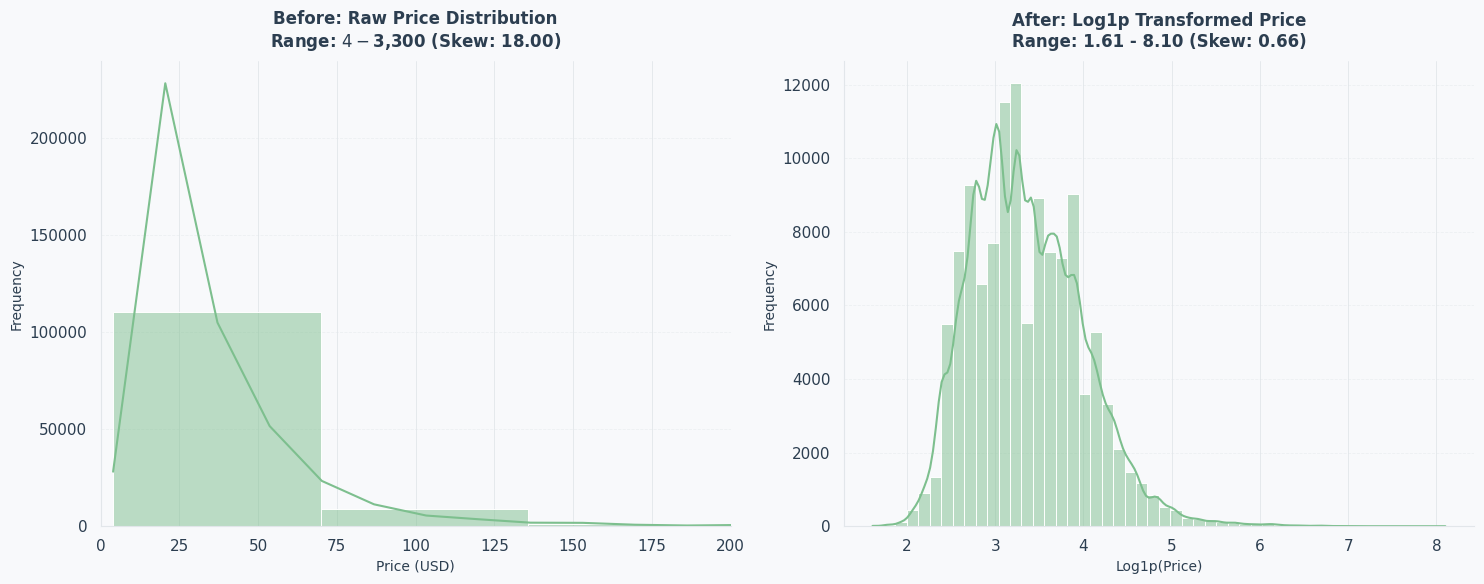

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Calculate Temporary Log Transformation ────────────────────────────────
# Drop NaNs just for the visualization to avoid plotting errors
raw_price = df['price'].dropna()
temp_log_price = np.log1p(raw_price)

# Calculate ranges and maximums
raw_max = raw_price.max()
log_max = temp_log_price.max()

raw_min = raw_price.min()
log_min = temp_log_price.min()

# Calculate exact statistical skewness
raw_skew = raw_price.skew()
log_skew = temp_log_price.skew()

print("=" * 65)
print("  📊 NUMBER RANGE & SKEWNESS COMPARISON (Before vs After)")
print("=" * 65)
print(f"  🔹 RAW PRICE RANGE      : ${raw_min:,.2f}  to  ${raw_max:,.2f}")
print(f"  🔹 LOG1P PRICE RANGE    : {log_min:.4f}  to  {log_max:.4f}")
print("-" * 65)
print(f"  💥 Raw Price Skewness   : {raw_skew:.4f}  (Highly Skewed Tail)")
print(f"  🎯 Log1p Price Skewness : {log_skew:.4f}   (Balanced Bell Curve)")
print("=" * 65)

# ── 2. Visual Comparison ─────────────────────────────────────────────────────
C_MAIN = "#7DBF8E"
BG     = "#F8F9FB"
TEXT   = "#2C3E50"

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

# Plot A: Raw Price (Highly Skewed)
sns.histplot(raw_price, bins=50, kde=True, color=C_MAIN, ax=axes[0], edgecolor='white')
axes[0].set_title(f"Before: Raw Price Distribution\nRange: ${raw_min:.0f} - ${raw_max:,.0f} (Skew: {raw_skew:.2f})",
                  fontsize=12, fontweight='bold', color=TEXT, pad=10)
axes[0].set_xlabel("Price (USD)", fontsize=10, color=TEXT)
axes[0].set_ylabel("Frequency", fontsize=10, color=TEXT)
axes[0].set_xlim(0, 200) # Capped at 200 strictly for zoom visibility
axes[0].set_facecolor(BG)

# Plot B: Log1p Price (Normalized)
sns.histplot(temp_log_price, bins=50, kde=True, color=C_MAIN, ax=axes[1], edgecolor='white')
axes[1].set_title(f"After: Log1p Transformed Price\nRange: {log_min:.2f} - {log_max:.2f} (Skew: {log_skew:.2f})",
                  fontsize=12, fontweight='bold', color=TEXT, pad=10)
axes[1].set_xlabel("Log1p(Price)", fontsize=10, color=TEXT)
axes[1].set_ylabel("Frequency", fontsize=10, color=TEXT)
axes[1].set_facecolor(BG)

# Clean up layout
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Notice: 'df' remains completely unchanged!

## 2.4: Heatmap For Numerical Columns and Some Categorical Columns.
Take note that, categorical columns must be encoded because heatmap is the numerical representation of the relationship between features.

Example : If the price is high, demand is also high, direct relationship, so, it's value will be 1.00 , total match.

But in our Framework, encoders and scalers are only inside the preprocess() functions, and they are later called in model training cells, so, meaning that, in this stage, we need to manually use encoders again, just for this demonstration.

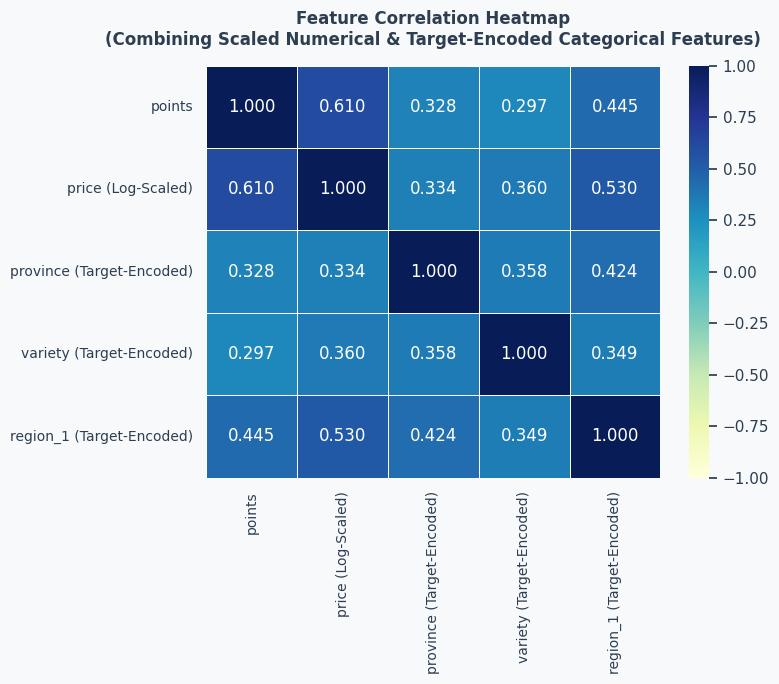

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import category_encoders as ce

# ── STEP 1: CREATE A LOCAL MOCK SPLIT FOR EDA ────────────────────────────────
X_mock = df.drop(columns=['points'])
y_mock = df['points']

X_train_mock, X_test_mock, y_train_mock, _ = train_test_split(
    X_mock, y_mock, test_size=0.10, random_state=42
)

# ── STEP 2: LOCAL TARGET ENCODING LOGIC ──────────────────────────────────────
X_train_processed = X_train_mock.copy()

# Apply log1p to price locally
X_train_processed['price'] = np.log1p(X_train_processed['price'])

# Target Encode high-cardinality features just for this chart's math
TARGET_COLS = ['province', 'variety', 'region_1']
te = ce.TargetEncoder(cols=TARGET_COLS, smoothing=1.0)
X_train_processed[TARGET_COLS] = te.fit_transform(X_train_processed[TARGET_COLS], y_train_mock)

# Add target back
X_train_processed['points'] = y_train_mock

# ── STEP 3: FILTER & PLOT HEATMAP ────────────────────────────────────────────
core_features = ['points', 'price', 'province', 'variety', 'region_1']
heatmap_data = X_train_processed[core_features].rename(columns={
    'price': 'price (Log-Scaled)',
    'province': 'province (Target-Encoded)',
    'variety': 'variety (Target-Encoded)',
    'region_1': 'region_1 (Target-Encoded)'
})

BG, TEXT = "#F8F9FB", "#2C3E50"
plt.figure(figsize=(8, 7), facecolor=BG)  # Slightly increased height to accommodate vertical labels safely
ax = plt.axes()
ax.set_facecolor(BG)

sns.heatmap(
    heatmap_data.corr(),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

plt.title("Feature Correlation Heatmap\n(Combining Scaled Numerical & Target-Encoded Categorical Features)",
          fontsize=12, fontweight='bold', pad=15, color=TEXT)

# 🎯 FIX: Changed rotation to 90 degrees and aligned to the center
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## 2.5: Preparing Predefined Preprocessor() Function For LIGHT GBM MODEL

In [17]:
print(df.dtypes)
print("All Categorical Columns are Nominal")

country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object
All Categorical Columns are Nominal


### Checking Type and Weight of each Features to Determine Their Encoder and Scaler

In [18]:
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
NLP_COLUMNS     = ['description', 'title']
NLP_WORD_THRESH = 6

# ── Select object columns from df ─────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Dataset']

# ── Build summary rows ────────────────────────────────────────────────────────
rows = []
for col in cat_cols:
    series    = df[col].dropna()
    n_unique  = series.nunique()
    avg_words = series.astype(str).str.split().str.len().mean()
    is_nlp    = (col in NLP_COLUMNS) or (avg_words >= NLP_WORD_THRESH)

    rows.append({
        'Feature Name'        : col,
        'Type'                : 'NLP (Free Text)' if is_nlp else 'Categorical',
        'Num Categories'      : None if is_nlp else n_unique,
        'Avg Words per Entry' : round(avg_words, 1),
        'Null Count'          : df[col].isnull().sum(),
        'Null %'              : f"{df[col].isnull().mean()*100:.1f}%",
    })

summary = pd.DataFrame(rows).sort_values(
    ['Type', 'Num Categories'],
    ascending=[True, True],
    na_position='last'
).reset_index(drop=True)

# ── Print table ───────────────────────────────────────────────────────────────
print("=" * 72)
print("  CATEGORICAL FEATURE OVERVIEW — Encoder Selection Guide")
print("=" * 72)
print(f"  {'Feature Name':<22} {'Type':<18} {'# Categories':>14} {'Nulls':>8}")
print("  " + "─" * 66)

for _, row in summary.iterrows():
    n_cat = str(int(row['Num Categories'])) if pd.notna(row['Num Categories']) else '—'
    nulls = f"{row['Null Count']:,} ({row['Null %']})" if row['Null Count'] > 0 else "None"
    print(f"  {row['Feature Name']:<22} {row['Type']:<18} {n_cat:>14} {nulls:>8}")

print("=" * 72)

# ── Custom Encoder Blueprint (Aligned perfectly with your pipeline) ───────────
print("\n  DESIGNED PIPELINE STRATEGY")
print("  " + "─" * 66)
for _, row in summary.iterrows():
    col_name = row['Feature Name']

    if row['Type'] == 'NLP (Free Text)':
        strategy = "TF-IDF Vectorization (Max Features)"
    elif col_name in ['country', 'taster_twitter_handle']:
        strategy = "One-Hot Encoding (Low Cardinality Nominal)"
    elif col_name in ['province', 'variety', 'region_1']:
        strategy = "Target Encoding (High Cardinality Mean Mapping)"
    elif col_name in ['winery', 'designation']:
        strategy = "Frequency Encoding (High Cardinality Representation)"
    else:
        strategy = "Pass-Through / Check Column Type"

    print(f"  {col_name:<22} →  {strategy}")

print("=" * 72)

  CATEGORICAL FEATURE OVERVIEW — Encoder Selection Guide
  Feature Name           Type                 # Categories    Nulls
  ──────────────────────────────────────────────────────────────────
  taster_twitter_handle  Categorical                    16     None
  country                Categorical                    42     None
  province               Categorical                   422     None
  variety                Categorical                   691     None
  region_1               Categorical                  1205     None
  winery                 Categorical                 15843     None
  designation            Categorical                 35754     None
  description            NLP (Free Text)                 —     None
  title                  NLP (Free Text)                 —     None

  DESIGNED PIPELINE STRATEGY
  ──────────────────────────────────────────────────────────────────
  taster_twitter_handle  →  One-Hot Encoding (Low Cardinality Nominal)
  country               

In [19]:
!pip install category_encoders

### Our Main Preprocessor Function preprocess_splits().
In this function, we Pre-define the encoders by following the consideration from upper section. We use scaler log1p() for the price, just like, the way we used in Data Distribution Section.

In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import category_encoders as ce

def preprocess_splits(X_train, X_test, y_train):
    """
    Applies all encoding and scaling rules sequentially to prevent data leakage.
    Fits ONLY on X_train, transforms both X_train and X_test.
    """
    # 1. ONE-HOT ENCODING (Low Cardinality)
    OHE_COLS = ['taster_twitter_handle', 'country']
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_train = pd.DataFrame(ohe.fit_transform(X_train[OHE_COLS]), columns=ohe.get_feature_names_out(OHE_COLS), index=X_train.index)
    ohe_test  = pd.DataFrame(ohe.transform(X_test[OHE_COLS]), columns=ohe.get_feature_names_out(OHE_COLS), index=X_test.index)
    X_train   = pd.concat([X_train.drop(columns=OHE_COLS), ohe_train], axis=1)
    X_test    = pd.concat([X_test.drop(columns=OHE_COLS), ohe_test], axis=1)

    # 2. TARGET ENCODING (High Cardinality Nominal)
    TARGET_COLS = ['province', 'variety', 'region_1']
    te = ce.TargetEncoder(cols=TARGET_COLS, smoothing=1.0)
    X_train[TARGET_COLS] = te.fit_transform(X_train[TARGET_COLS], y_train)
    X_test[TARGET_COLS]  = te.transform(X_test[TARGET_COLS])

    # 3. FREQUENCY ENCODING (High Cardinality Representation)
    FREQ_COLS = ['winery', 'designation']
    for col in FREQ_COLS:
        freq_map = X_train[col].value_counts(normalize=True)
        X_train[col] = X_train[col].map(freq_map)
        X_test[col]  = X_test[col].map(freq_map).fillna(0)

    # 4. TF-IDF ENCODING (Free Text)
    NLP_COLS = ['description', 'title']
    MAX_FEATS = {'description': 100, 'title': 50}
    tfidf_train_parts, tfidf_test_parts = [], []
    for col in NLP_COLS:
        tfidf = TfidfVectorizer(max_features=MAX_FEATS[col], stop_words='english')
        mat_train = tfidf.fit_transform(X_train[col].astype(str))
        mat_test  = tfidf.transform(X_test[col].astype(str))
        cols = [f"{col}_tfidf_{t}" for t in tfidf.get_feature_names_out()]
        tfidf_train_parts.append(pd.DataFrame(mat_train.toarray(), columns=cols, index=X_train.index))
        tfidf_test_parts.append(pd.DataFrame(mat_test.toarray(), columns=cols, index=X_test.index))
    X_train = pd.concat([X_train.drop(columns=NLP_COLS)] + tfidf_train_parts, axis=1)
    X_test  = pd.concat([X_test.drop(columns=NLP_COLS)] + tfidf_test_parts, axis=1)

    # 5. FEATURE SCALING & LOG TRANSFORM
    continuous_cols = [col for col in X_train.columns if X_train[col].nunique() > 2]
    X_train['price'] = np.log1p(X_train['price'])
    X_test['price']  = np.log1p(X_test['price'])

    scaler = StandardScaler()
    X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])

    return X_train, X_test

print("✔ Preprocessing Function successfully defined and ready!")

✔ Preprocessing Function successfully defined and ready!


# Section 3: One by One Demonstration of Each Encodings and Scalings

As our encodings and scalings are implemented in pre-defined function(), it is not yet called yet. For report writing backup, this is just one by one demonstration and nothing related with the program actually, just for demonstration.

We are using variables that we will never ever use again.

In [21]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — ONE-HOT ENCODING DEMO  [ taster_twitter_handle ]
# ═══════════════════════════════════════════════════════════════
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe_demo = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_array = ohe_demo.fit_transform(df[['taster_twitter_handle']])
ohe_cols  = ohe_demo.get_feature_names_out(['taster_twitter_handle'])

ohe_result = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
ohe_result.insert(0, 'taster_twitter_handle', df['taster_twitter_handle'])

print(f"Total OHE columns generated : {len(ohe_cols)}  (1 per class)")
print(f"Classes                     : {list(df['taster_twitter_handle'].unique())}\n")
ohe_result.head(6)

Total OHE columns generated : 16  (1 per class)
Classes                     : ['@vossroger', '@paulgwine\xa0', 'Unknown', '@wineschach', '@kerinokeefe', '@vboone', '@mattkettmann', '@wawinereport', '@gordone_cellars', '@JoeCz', '@AnneInVino', '@laurbuzz', '@worldwineguys', '@suskostrzewa', '@bkfiona', '@winewchristina']



,taster_twitter_handle,taster_twitter_handle_@AnneInVino,taster_twitter_handle_@JoeCz,taster_twitter_handle_@bkfiona,taster_twitter_handle_@gordone_cellars,taster_twitter_handle_@kerinokeefe,taster_twitter_handle_@laurbuzz,taster_twitter_handle_@mattkettmann,taster_twitter_handle_@paulgwine,taster_twitter_handle_@suskostrzewa,taster_twitter_handle_@vboone,taster_twitter_handle_@vossroger,taster_twitter_handle_@wawinereport,taster_twitter_handle_@wineschach,taster_twitter_handle_@winewchristina,taster_twitter_handle_@worldwineguys,taster_twitter_handle_Unknown
1,@vossroger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,@paulgwine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,@paulgwine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,@wineschach,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,@kerinokeefe,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# ═══════════════════════════════════════════════════════════════
#  CELL 2 — TARGET ENCODING DEMO  [ province → 'California' ]
# ═══════════════════════════════════════════════════════════════
DEMO_PROVINCE = 'California'

subset = df[df['province'] == DEMO_PROVINCE][['province', 'points']].copy()

total_points   = subset['points'].sum()
count          = len(subset)
encoded_value  = total_points / count

subset['encoded_value'] = encoded_value
subset['calculation']   = f"{total_points} / {count} = {encoded_value:.6f}"

print("=" * 60)
print(f"  Province        : {DEMO_PROVINCE}")
print(f"  Total of points : {total_points:,}")
print(f"  Record count    : {count:,}")
print(f"  Encoded value   : {total_points:,} / {count:,} = {encoded_value:.6f}")
print("=" * 60)
subset[['province', 'points', 'encoded_value', 'calculation']].head(6)

  Province        : California
  Total of points : 3,199,880
  Record count    : 36,104
  Encoded value   : 3,199,880 / 36,104 = 88.629515


,province,points,encoded_value,calculation
10,California,87,88.629515,3199880 / 36104 = 88.629515
12,California,87,88.629515,3199880 / 36104 = 88.629515
14,California,87,88.629515,3199880 / 36104 = 88.629515
23,California,87,88.629515,3199880 / 36104 = 88.629515
25,California,87,88.629515,3199880 / 36104 = 88.629515
29,California,86,88.629515,3199880 / 36104 = 88.629515


In [23]:
# ═══════════════════════════════════════════════════════════════
#  CELL 3 — FREQUENCY ENCODING DEMO  [ winery → Top 1 winery ]
# ═══════════════════════════════════════════════════════════════
DEMO_WINERY = df['winery'].value_counts().index[0]   # most frequent winery

total_records    = len(df)
winery_count     = (df['winery'] == DEMO_WINERY).sum()
frequency_value  = winery_count / total_records

subset = df[df['winery'] == DEMO_WINERY][['winery', 'points', 'price']].copy()
subset['encoded_value'] = frequency_value
subset['calculation']   = f"{winery_count} / {total_records} = {frequency_value:.6f}"

print("=" * 60)
print(f"  Winery          : {DEMO_WINERY}")
print(f"  Appearances     : {winery_count:,}")
print(f"  Total records   : {total_records:,}")
print(f"  Encoded value   : {winery_count:,} / {total_records:,} = {frequency_value:.6f}")
print("=" * 60)
subset[['winery', 'points', 'price', 'encoded_value', 'calculation']].head(6)

  Winery          : Testarossa
  Appearances     : 217
  Total records   : 120,915
  Encoded value   : 217 / 120,915 = 0.001795


,winery,points,price,encoded_value,calculation
145,Testarossa,91,64.0,0.001795,217 / 120915 = 0.001795
235,Testarossa,85,49.0,0.001795,217 / 120915 = 0.001795
525,Testarossa,91,49.0,0.001795,217 / 120915 = 0.001795
3827,Testarossa,93,39.0,0.001795,217 / 120915 = 0.001795
3828,Testarossa,93,79.0,0.001795,217 / 120915 = 0.001795
5683,Testarossa,88,75.0,0.001795,217 / 120915 = 0.001795


In [24]:
# ═══════════════════════════════════════════════════════════════
#  CELL 4 — STANDARD SCALER DEMO  [ Target Encoded → province ]
# ═══════════════════════════════════════════════════════════════
import category_encoders as ce
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Target encode province (same as pipeline)
te_demo = ce.TargetEncoder(cols=['province'], smoothing=1.0)
province_encoded = te_demo.fit_transform(df[['province']], df['points'])
province_encoded.columns = ['province_target_encoded']

# Step 2: Standard scale it
scaler_demo = StandardScaler()
province_scaled = scaler_demo.fit_transform(province_encoded)

# Step 3: Build comparison table
demo_df = pd.DataFrame({
    'province'         : df['province'].values,
    'target_encoded'   : province_encoded['province_target_encoded'].values,
    'scaled_value'     : province_scaled.flatten(),
    'calculation'      : [
        f"({te:.6f} - {scaler_demo.mean_[0]:.6f}) / {scaler_demo.scale_[0]:.6f}"
        for te in province_encoded['province_target_encoded'].values
    ]
})

print("=" * 70)
print("  TARGET ENCODING → STANDARD SCALER  [ province ]")
print("=" * 70)
print(f"  Scaler Mean  : {scaler_demo.mean_[0]:.6f}")
print(f"  Scaler Std   : {scaler_demo.scale_[0]:.6f}")
print("=" * 70)
demo_df.drop_duplicates('province').head(6)

  TARGET ENCODING → STANDARD SCALER  [ province ]
  Scaler Mean  : 88.434458
  Scaler Std   : 1.001746


,province,target_encoded,scaled_value,calculation
0,Douro,89.139330,0.703643,(89.139330 - 88.434458) / 1.001746
1,Oregon,89.053741,0.618204,(89.053741 - 88.434458) / 1.001746
2,Michigan,86.153153,-2.277328,(86.153153 - 88.434458) / 1.001746
4,Northern Spain,87.420595,-1.012095,(87.420595 - 88.434458) / 1.001746
5,Sicily & Sardinia,88.192431,-0.241605,(88.192431 - 88.434458) / 1.001746
6,Alsace,89.603167,1.166672,(89.603167 - 88.434458) / 1.001746


In [25]:
# ═══════════════════════════════════════════════════════════════
#  CELL 5 — STANDARD SCALER DEMO  [ Freq Encoded → winery ]
# ═══════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Frequency encode winery (same as pipeline)
freq_map        = df['winery'].value_counts(normalize=True)
winery_encoded  = df['winery'].map(freq_map)

# Step 2: Standard scale it
scaler_freq   = StandardScaler()
winery_scaled = scaler_freq.fit_transform(winery_encoded.values.reshape(-1, 1))

# Step 3: Build comparison table
demo_df2 = pd.DataFrame({
    'winery'           : df['winery'].values,
    'freq_encoded'     : winery_encoded.values,
    'scaled_value'     : winery_scaled.flatten(),
    'calculation'      : [
        f"({fe:.6f} - {scaler_freq.mean_[0]:.6f}) / {scaler_freq.scale_[0]:.6f}"
        for fe in winery_encoded.values
    ]
})

print("=" * 70)
print("  FREQUENCY ENCODING → STANDARD SCALER  [ winery ]")
print("=" * 70)
print(f"  Scaler Mean  : {scaler_freq.mean_[0]:.6f}")
print(f"  Scaler Std   : {scaler_freq.scale_[0]:.6f}")
print("=" * 70)
demo_df2.drop_duplicates('winery').head(6)

  FREQUENCY ENCODING → STANDARD SCALER  [ winery ]
  Scaler Mean  : 0.000233
  Scaler Std   : 0.000260


,winery,freq_encoded,scaled_value,calculation
0,Quinta dos Avidagos,0.000066,-0.642000,(0.000066 - 0.000233) / 0.000260
1,Rainstorm,0.000116,-0.451514,(0.000116 - 0.000233) / 0.000260
2,St. Julian,0.000083,-0.578504,(0.000083 - 0.000233) / 0.000260
3,Sweet Cheeks,0.000149,-0.324523,(0.000149 - 0.000233) / 0.000260
4,Tandem,0.000132,-0.388018,(0.000132 - 0.000233) / 0.000260
5,Terre di Giurfo,0.000083,-0.578504,(0.000083 - 0.000233) / 0.000260


# Section 4: LightGBM Model

## 4.1: Hyper Parameter Tuning

In [26]:
!pip install lightgbm -q

### First Stage of Tuning.

In here, we consider these matrics for the model estimators_grid = [200, 300, 500, 700], lr_grid = [0.01, 0.03, 0.05, 0.1] and build the temporary model to see how it goes.

Check the output, we see that, the R2_score keep rising, so, we have to fine-tune with more parameters in the next cell.

In here, you look around here very carefully [ X_tr_proc, X_te_proc = preprocess_splits(X_tr, X_te, y_tr) ] and go back to [ Preparing Predefined Preprocessor() Function For LIGHT GBM MODEL] section again. We are giving the three Parameters to get the X_train and X_test back, which are encoded and scaled inside that preprocess_splits() function, so all are ready

In [27]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET = 'points'
SPLITS = [0.50, 0.40, 0.30, 0.20, 0.10]

X_base = df.drop(columns=[TARGET])
y_base = df[TARGET]

# ── Step 1 : Manual Tuning Grid (4x4 = 16 Models) ───────────────────────────
print("=" * 65)
print("  🔍 PHASE 1 — MANUAL HYPERPARAMETER TUNING (16 Combinations)")
print("=" * 65)

# Split and preprocess ONCE for tuning to save extreme amounts of time
X_tr, X_te, y_tr, y_te = train_test_split(
    X_base, y_base, test_size=0.20, random_state=42
)
print("⏳ Preprocessing tuning data split...")
X_tr_proc, X_te_proc = preprocess_splits(X_tr, X_te, y_tr)

# Define your grid
estimators_grid = [200, 300, 500, 700]
lr_grid = [0.01, 0.03, 0.05, 0.1]

best_r2 = -float('inf')
best_lgb_params = {}

print("\n🚀 Starting Grid Search...")
print(f"{'n_estimators':<15} | {'learning_rate':<15} | {'Val R2 Score':<15}")
print("-" * 55)

for n_est in estimators_grid:
    for lr in lr_grid:
        # Construct model with fixed default parameters for the rest
        model = lgb.LGBMRegressor(
            objective='regression',
            boosting_type='gbdt',
            n_estimators=n_est,
            learning_rate=lr,
            num_leaves=63,            # Fixed stable default
            min_child_samples=20,     # Fixed stable default
            subsample=0.8,            # Fixed stable default
            colsample_bytree=0.8,     # Fixed stable default
            device='gpu',             # Uses Colab T4 GPU
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )

        # Fit model quickly
        model.fit(X_tr_proc, y_tr)

        # Evaluate on validation split
        preds = model.predict(X_te_proc)
        current_r2 = r2_score(y_te, preds)

        print(f"{n_est:<15} | {lr:<15} | {current_r2:.4f}")

        # Track the absolute best configuration
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_lgb_params = {
                'n_estimators': n_est,
                'learning_rate': lr,
                'num_leaves': 63,
                'min_child_samples': 20,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }

print(f"\n✔ Best Validation R2 Achieved: {best_r2:.4f}")
print("✔ Best Parameters Found:")
for k, v in best_lgb_params.items():
    print(f"   {k:<22} : {v}")


# ── Step 2 : Evaluate across all splits using best params ────────────────────
print("\n" + "=" * 65)
print("  🚀 PHASE 2 — SPLIT EVALUATION  (Best Manual Params)")
print("=" * 65)

lgb_results = []

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    print(f"\n➤  Processing Split: {train_pct}% Train / {test_pct}% Test ...")

    X_train, X_test, y_train, y_test = train_test_split(
        X_base, y_base, test_size=test_size, random_state=42
    )
    X_train_clean, X_test_clean = preprocess_splits(X_train, X_test, y_train)

    final_model = lgb.LGBMRegressor(
        **best_lgb_params,
        objective     = 'regression',
        boosting_type = 'gbdt',
        device        = 'gpu',
        n_jobs        = -1,
        random_state  = 42,
        verbose       = -1,
    )

    final_model.fit(
        X_train_clean, y_train,
        eval_set  = [(X_test_clean, y_test)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)],
    )

    predictions = final_model.predict(X_test_clean)

    # Generate full suite of regression metrics
    mae  = mean_absolute_error(y_test, predictions)
    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)

    lgb_results.append({
        'Train %'   : train_pct,
        'Test %'    : test_pct,
        'R2 Score'  : round(r2, 4),
        'MAE'       : round(mae, 4),
        'MSE'       : round(mse, 4),
        'RMSE'      : round(rmse, 4),
        'Best Iter' : final_model.best_iteration_,
    })
    print(f"   ✔ R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

df_lgb_results = pd.DataFrame(lgb_results)
print("\n" + "=" * 65)
print("  🏆 LIGHTGBM — FINAL REPORT")
print("=" * 65)
print(df_lgb_results.to_string(index=False))
print("=" * 65)

  🔍 PHASE 1 — MANUAL HYPERPARAMETER TUNING (16 Combinations)
⏳ Preprocessing tuning data split...

🚀 Starting Grid Search...
n_estimators    | learning_rate   | Val R2 Score   
-------------------------------------------------------
200             | 0.01            | 0.5314
200             | 0.03            | 0.6302
200             | 0.05            | 0.6488
200             | 0.1             | 0.6578
300             | 0.01            | 0.5765
300             | 0.03            | 0.6465
300             | 0.05            | 0.6562
300             | 0.1             | 0.6632
500             | 0.01            | 0.6201
500             | 0.03            | 0.6573
500             | 0.05            | 0.6642
500             | 0.1             | 0.6694
700             | 0.01            | 0.6381
700             | 0.03            | 0.6629
700             | 0.05            | 0.6697
700             | 0.1             | 0.6733

✔ Best Validation R2 Achieved: 0.6733
✔ Best Parameters Found:
   n_estimators

### Second Stage of Tuning.

In here, as in first stage, n_estimators = 700 was the best on learning_rates of [ 0.05 and 0.1 ], we sill start from 800 to see is r2_score() will keep rising?

In [28]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET = 'points'

X_base = df.drop(columns=[TARGET])
y_base = df[TARGET]

print("=" * 65)
print("  🔍 PHASE 1.2 — EXTENDED HYPERPARAMETER TUNING")
print("=" * 65)

# Independent train/test split execution
X_tr, X_te, y_tr, y_te = train_test_split(
    X_base, y_base, test_size=0.20, random_state=42
)
print("⏳ Preprocessing tuning data split...")
X_tr_proc, X_te_proc = preprocess_splits(X_tr, X_te, y_tr)

# New extended tree grid based on your discovery
estimators_grid = [800, 1000, 1200, 1400]
lr_grid = [0.05, 0.1]

best_r2 = -float('inf')
best_lgb_params = {}

print("\n🚀 Starting Extended Grid Search...")
print(f"{'n_estimators':<15} | {'learning_rate':<15} | {'Val R2 Score':<15}")
print("-" * 55)

for n_est in estimators_grid:
    for lr in lr_grid:
        model = lgb.LGBMRegressor(
            objective='regression',
            boosting_type='gbdt',
            n_estimators=n_est,
            learning_rate=lr,
            num_leaves=63,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            device='gpu',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )

        model.fit(X_tr_proc, y_tr)
        preds = model.predict(X_te_proc)
        current_r2 = r2_score(y_te, preds)

        print(f"{n_est:<15} | {lr:<15} | {current_r2:.4f}")

        if current_r2 > best_r2:
            best_r2 = current_r2
            best_lgb_params = {
                'n_estimators': n_est,
                'learning_rate': lr,
                'num_leaves': 63,
                'min_child_samples': 20,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }

print(f"\n✔ New Best Validation R2 Achieved: {best_r2:.4f}")
print("✔ Best Upgraded Parameters Found:")
for k, v in best_lgb_params.items():
    print(f"   {k:<22} : {v}")

  🔍 PHASE 1.2 — EXTENDED HYPERPARAMETER TUNING
⏳ Preprocessing tuning data split...

🚀 Starting Extended Grid Search...
n_estimators    | learning_rate   | Val R2 Score   
-------------------------------------------------------
800             | 0.05            | 0.6716
800             | 0.1             | 0.6750
1000            | 0.05            | 0.6751
1000            | 0.1             | 0.6770
1200            | 0.05            | 0.6778
1200            | 0.1             | 0.6787
1400            | 0.05            | 0.6797
1400            | 0.1             | 0.6798

✔ New Best Validation R2 Achieved: 0.6798
✔ Best Upgraded Parameters Found:
   n_estimators           : 1400
   learning_rate          : 0.1
   num_leaves             : 63
   min_child_samples      : 20
   subsample              : 0.8
   colsample_bytree       : 0.8


But in here in stage 2, we notice that, compared to stage 1 best [ n_estimators = 700 with learning_rate = 0.1, which gives the r2_score of 0.6733 ] , this second tuning did not make much progress even though, we have many trees used. So, this is the performance cap.

In [29]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET = 'points'
SPLITS = [0.50, 0.40, 0.30, 0.20, 0.10]

X_base = df.drop(columns=[TARGET])
y_base = df[TARGET]

print("=" * 65)
print("  🚀 PHASE 2 — FINAL SPLIT EVALUATION (Best Upgraded Params)")
print("=" * 65)

# Lock down your winning parameters from the extended grid search
best_lgb_params = {
    'n_estimators': 1400,
    'learning_rate': 0.1,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

lgb_results = []

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    print(f"\n➤  Processing Split: {train_pct}% Train / {test_pct}% Test ...")

    # Split the original base data freshly for this ratio
    X_train, X_test, y_train, y_test = train_test_split(
        X_base, y_base, test_size=test_size, random_state=42
    )

    # Preprocess the splits independently to prevent leakage
    X_train_clean, X_test_clean = preprocess_splits(X_train, X_test, y_train)

    # Initialize the final model with the absolute best params
    final_model = lgb.LGBMRegressor(
        **best_lgb_params,
        objective     = 'regression',
        boosting_type = 'gbdt',
        device        = 'gpu',          # Keeping T4 GPU active
        n_jobs        = -1,
        random_state  = 42,
        verbose       = -1,
    )

    # Fit the model with early stopping to safeguard against overfitting
    final_model.fit(
        X_train_clean, y_train,
        eval_set  = [(X_test_clean, y_test)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)],
    )

    # Predict and evaluate
    predictions = final_model.predict(X_test_clean)

    mae  = mean_absolute_error(y_test, predictions)
    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)

    lgb_results.append({
        'Train %'   : train_pct,
        'Test %'    : test_pct,
        'R2 Score'  : round(r2, 4),
        'MAE'       : round(mae, 4),
        'MSE'       : round(mse, 4),
        'RMSE'      : round(rmse, 4),
        'Best Iter' : final_model.best_iteration_,
    })
    print(f"   ✔ R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

# Generate the final structured overview report
df_lgb_results = pd.DataFrame(lgb_results)
print("\n" + "=" * 65)
print("  🏆 LIGHTGBM — FINAL UPGRADED REPORT")
print("=" * 65)
print(df_lgb_results.to_string(index=False))
print("=" * 65)

  🚀 PHASE 2 — FINAL SPLIT EVALUATION (Best Upgraded Params)

➤  Processing Split: 50% Train / 50% Test ...
   ✔ R2: 0.6602 | MAE: 1.3706 | MSE: 3.1468 | RMSE: 1.7739

➤  Processing Split: 60% Train / 40% Test ...
   ✔ R2: 0.6701 | MAE: 1.3430 | MSE: 3.0581 | RMSE: 1.7487

➤  Processing Split: 70% Train / 30% Test ...
   ✔ R2: 0.6764 | MAE: 1.3296 | MSE: 3.0024 | RMSE: 1.7327

➤  Processing Split: 80% Train / 20% Test ...
   ✔ R2: 0.6799 | MAE: 1.3259 | MSE: 2.9846 | RMSE: 1.7276

➤  Processing Split: 90% Train / 10% Test ...
   ✔ R2: 0.6877 | MAE: 1.3108 | MSE: 2.9300 | RMSE: 1.7117

  🏆 LIGHTGBM — FINAL UPGRADED REPORT
 Train %  Test %  R2 Score    MAE    MSE   RMSE  Best Iter
      50      50    0.6602 1.3706 3.1468 1.7739        855
      60      40    0.6701 1.3430 3.0581 1.7487       1397
      70      30    0.6764 1.3296 3.0024 1.7327       1374
      80      20    0.6799 1.3259 2.9846 1.7276       1396
      90      10    0.6877 1.3108 2.9300 1.7117       1398


### Third Stage of Tuning.

In this stage, we will take n_estimators starting from 1600 but we do not consider the learning_rate anymore.

Instead, we will consider another important parameter called num_leaves, and will consider between 127 and 255, which is twice.

In [30]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET = 'points'
SPLITS = [0.50, 0.40, 0.30, 0.20, 0.10]

X_base = df.drop(columns=[TARGET])
y_base = df[TARGET]

# ── Step 1 : Aggressive Hyperparameter Tuning ───────────────────────────────
print("=" * 65)
print("  🔍 PHASE 1.3 — AGGRESSIVE TUNING (Targeting >0.70 R2)")
print("=" * 65)

# Fixed split dedicated strictly for high-capacity tuning
X_tr, X_te, y_tr, y_te = train_test_split(
    X_base, y_base, test_size=0.20, random_state=42
)
print("⏳ Preprocessing tuning data split...")
X_tr_proc, X_te_proc = preprocess_splits(X_tr, X_te, y_tr)

# Aggressive high-capacity grid adjustments
estimators_grid = [1600, 2000]
leaves_grid = [127, 255]

best_r2 = -float('inf')
best_lgb_params = {}

print("\n🚀 Starting Phase 1.3 Grid Search...")
print(f"{'n_estimators':<15} | {'num_leaves':<15} | {'Val R2 Score':<15}")
print("-" * 55)

for n_est in estimators_grid:
    for num_leaves in leaves_grid:
        model = lgb.LGBMRegressor(
            objective='regression',
            boosting_type='gbdt',
            n_estimators=n_est,
            learning_rate=0.1,
            num_leaves=num_leaves,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            device='gpu',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )

        model.fit(X_tr_proc, y_tr)
        preds = model.predict(X_te_proc)
        current_r2 = r2_score(y_te, preds)

        print(f"{n_est:<15} | {num_leaves:<15} | {current_r2:.4f}")

        if current_r2 > best_r2:
            best_r2 = current_r2
            best_lgb_params = {
                'n_estimators': n_est,
                'learning_rate': 0.1,
                'num_leaves': num_leaves,
                'min_child_samples': 20,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }

print(f"\n✔ Phase 1.3 Best Validation R2 Achieved: {best_r2:.4f}")
print("✔ Best High-Capacity Parameters Found:")
for k, v in best_lgb_params.items():
    print(f"   {k:<22} : {v}")


# ── Step 2 : Multi-Split Evaluation using Phase 1.3 Best Params ──────────────
print("\n" + "=" * 65)
print("  🚀 PHASE 2 — FINAL DATA SPLIT EVALUATION (All Metrics)")
print("=" * 65)

lgb_results = []

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    print(f"\n➤  Processing Split: {train_pct}% Train / {test_pct}% Test ...")

    # Re-split data cleanly for this specific ratio
    X_train, X_test, y_train, y_test = train_test_split(
        X_base, y_base, test_size=test_size, random_state=42
    )
    X_train_clean, X_test_clean = preprocess_splits(X_train, X_test, y_train)

    # Initialize the final model with our fresh high-capacity champion parameters
    final_model = lgb.LGBMRegressor(
        **best_lgb_params,
        objective     = 'regression',
        boosting_type = 'gbdt',
        device        = 'gpu',
        n_jobs        = -1,
        random_state  = 42,
        verbose       = -1,
    )

    final_model.fit(
        X_train_clean, y_train,
        eval_set  = [(X_test_clean, y_test)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)],
    )

    predictions = final_model.predict(X_test_clean)

    # Calculate complete regression breakdown metrics
    mae  = mean_absolute_error(y_test, predictions)
    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)

    lgb_results.append({
        'Train %'   : train_pct,
        'Test %'    : test_pct,
        'R2 Score'  : round(r2, 4),
        'MAE'       : round(mae, 4),
        'MSE'       : round(mse, 4),
        'RMSE'      : round(rmse, 4),
        'Best Iter' : final_model.best_iteration_,
    })
    print(f"   ✔ R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

# Generate structured tabular overview
df_lgb_results = pd.DataFrame(lgb_results)
print("\n" + "=" * 65)
print("  🏆 LIGHTGBM — FINAL HIGH-CAPACITY PERFORMANCE REPORT")
print("=" * 65)
print(df_lgb_results.to_string(index=False))
print("=" * 65)

  🔍 PHASE 1.3 — AGGRESSIVE TUNING (Targeting >0.70 R2)
⏳ Preprocessing tuning data split...

🚀 Starting Phase 1.3 Grid Search...
n_estimators    | num_leaves      | Val R2 Score   
-------------------------------------------------------
1600            | 127             | 0.6858
1600            | 255             | 0.6870
2000            | 127             | 0.6862
2000            | 255             | 0.6873

✔ Phase 1.3 Best Validation R2 Achieved: 0.6873
✔ Best High-Capacity Parameters Found:
   n_estimators           : 2000
   learning_rate          : 0.1
   num_leaves             : 255
   min_child_samples      : 20
   subsample              : 0.8
   colsample_bytree       : 0.8

  🚀 PHASE 2 — FINAL DATA SPLIT EVALUATION (All Metrics)

➤  Processing Split: 50% Train / 50% Test ...
   ✔ R2: 0.6640 | MAE: 1.3461 | MSE: 3.1116 | RMSE: 1.7640

➤  Processing Split: 60% Train / 40% Test ...
   ✔ R2: 0.6724 | MAE: 1.3222 | MSE: 3.0366 | RMSE: 1.7426

➤  Processing Split: 70% Train / 30% Test

### Evaluation for Tuning.

After three stages of tuning, we see not much progress of R2 Score progress beyond 0.69 ( almost 70% ) and this is acceptable because, almost all of our features are categorical.

Even though, LightGBM is a boosting Algorithm, which is well-fit to large hundreds of thousands of records datasets, but it is not Ideal for Categorical Based Features, so, for our Second Model, we will use the CatBoost model which is well-recommended for categorical-heavy dataset.

## 4.2: Final LightGBM Model with metrics from Hyperparameter Tuning

Acutally, in HyperParameter tuning, we are actually training and evaluating the models. So, all the splits [ 50/50, 60/40, 70/30, 80/20, 90/10 ] are already trained in finalized stage in Third Stage of Tuning. The cell is like, just finalized showcasing of the best split [90/10].

In [31]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET_VARIABLE = 'points'

# Using entirely fresh variable names for data initialization
lgb_final_X_base = df.drop(columns=[TARGET_VARIABLE])
lgb_final_y_base = df[TARGET_VARIABLE]

print("=" * 65)
print("  🎯 FINAL PRODUCTION MODEL TRAINING — SNIPER OPERATION")
print("=" * 65)

# Setting up the optimal 90/10 split to maximize training volume
print("⏳ Splitting data (90% Train / 10% Test)...")
lgb_final_X_train, lgb_final_X_test, lgb_final_y_train, lgb_final_y_test = train_test_split(
    lgb_final_X_base, lgb_final_y_base, test_size=0.10, random_state=42
)

print("⏳ Running independent preprocessing pipeline...")
lgb_final_X_train_proc, lgb_final_X_test_proc = preprocess_splits(
    lgb_final_X_train, lgb_final_X_test, lgb_final_y_train
)

# Sniper configuration parameters
sniper_hyperparameters = {
    'n_estimators': 1600,
    'learning_rate': 0.1,
    'num_leaves': 255,
    'min_child_samples': 20,     # Optimized to stabilize complex trees
    'subsample': 0.80,           # Higher sample rate for deeper insights
    'colsample_bytree': 0.80     # Better capture of low-frequency text patterns
}

print("\n🚀 Training lightgbm_model on T4 GPU...")
lightgbm_model = lgb.LGBMRegressor(
    **sniper_hyperparameters,
    objective='regression',
    boosting_type='gbdt',
    device='gpu',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# Training execution with an active safety evaluation set
lightgbm_model.fit(
    lgb_final_X_train_proc, lgb_final_y_train,
    eval_set=[(lgb_final_X_test_proc, lgb_final_y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

print("\n📊 Generating production evaluation reports...")
lightgbm_final_predictions = lightgbm_model.predict(lgb_final_X_test_proc)

# Calculating standard regression evaluation suite
production_mae = mean_absolute_error(lgb_final_y_test, lightgbm_final_predictions)
production_mse = mean_squared_error(lgb_final_y_test, lightgbm_final_predictions)
production_rmse = np.sqrt(production_mse)
production_r2 = r2_score(lgb_final_y_test, lightgbm_final_predictions)

print("-" * 65)
print(f"       🏆 FINAL PERFORMANCE METRICS BREAKDOWN")
print("-" * 65)
print(f"  ⭐ R-squared Score (R2) : {production_r2:.4f}")

print(f"  🔹 Mean Absolute Error (MAE)  : {production_mae:.4f}")
print(f"  🔹 Mean Squared Error (MSE)   : {production_mse:.4f}")
print(f"  🔹 Root Mean Squared Error (RMSE): {production_rmse:.4f}")
print(f"  🔹 Peak Iteration Multiplier  : {lightgbm_model.best_iteration_}")
print("=" * 65)

  🎯 FINAL PRODUCTION MODEL TRAINING — SNIPER OPERATION
⏳ Splitting data (90% Train / 10% Test)...
⏳ Running independent preprocessing pipeline...

🚀 Training lightgbm_model on T4 GPU...

📊 Generating production evaluation reports...
-----------------------------------------------------------------
       🏆 FINAL PERFORMANCE METRICS BREAKDOWN
-----------------------------------------------------------------
  ⭐ R-squared Score (R2) : 0.6937
  🔹 Mean Absolute Error (MAE)  : 1.2679
  🔹 Mean Squared Error (MSE)   : 2.8742
  🔹 Root Mean Squared Error (RMSE): 1.6953
  🔹 Peak Iteration Multiplier  : 1016


# Section 5: CatBoost Model

This model is highly Ideal for the datasets with a lot of Categorical Columns, because, it's native modules can handle the encoding and scaling by itselves. Check again the [Missing Values Handling Part], we do not need to do anything for this model also, because, for majority of missing Values columns, we either drop the whole column or all the rows. Moreover, filling 'Unknown' for columns such as ['designation', 'region_1', 'taster_twitter_handle'] these are also totally compatible.

For the 'price', we can just drop that 6.9% in row-wise for this one also which avoids bias because, 'price' is the most important column for predicting the target = 'points'.

Conclusion : We do not need to do any specific [ Handling Missing Values ] for this Model. Can use the same df.

## 5.1: 100% Fit, 0% Predict. (Training & Early Stopping)

In [32]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [33]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

TARGET_VARIABLE = 'points'
SPLITS = [0.50, 0.40, 0.30, 0.20, 0.10]

# ── STEP 1: Predefining the Preprocessing Function
def preprocess_for_catboost_native(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = ['taster_twitter_handle', 'country', 'province', 'variety', 'region_1', 'winery', 'designation']
    text_cols = ['description', 'title']

    # Force categorical columns to string type
    for col in cat_cols:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

    # Force text columns to string type
    for col in text_cols:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

    # Apply log transform to price
    X_train['price'] = np.log1p(X_train['price'])
    X_test['price'] = np.log1p(X_test['price'])

    return X_train, X_test, cat_cols, text_cols


print("=" * 65)
print("  🚀 PHASE 2 — MULTI-SPLIT TRAINING (NATIVE CATBOOST)")
print("=" * 65)

# Separate features and target from your clean df
cb_multi_X_base = df.drop(columns=[TARGET_VARIABLE])
cb_multi_y_base = df[TARGET_VARIABLE]

# Dictionary to hold data and models so Cell 2 can access them
trained_cb_models = {}

# ── STEP 2: Calling the preprocess function by giving [ cb_X_train, cb_X_test ] to it and getting the preprocessed ready [cb_X_train_proc, cb_X_test_proc, CATEGORICAL_FEATURES, TEXT_FEATURES ]
for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    split_key = f"{train_pct}/{test_pct}"

    print(f"⏳ Training Split: {train_pct}% Train / {test_pct}% Test on T4 GPU...")

    # Re-split data cleanly for this specific ratio
    cb_X_train, cb_X_test, cb_y_train, cb_y_test = train_test_split(
        cb_multi_X_base, cb_multi_y_base, test_size=test_size, random_state=42
    )

    # Process the features natively
    cb_X_train_proc, cb_X_test_proc, CATEGORICAL_FEATURES, TEXT_FEATURES = preprocess_for_catboost_native(
        cb_X_train, cb_X_test
    )

    # Initialize model with your optimized hyperparameters
    multi_catboost_model = CatBoostRegressor(
        iterations=3500,
        learning_rate=0.1,
        depth=8,
        cat_features=CATEGORICAL_FEATURES,
        text_features=TEXT_FEATURES,
        task_type="GPU",
        random_seed=42,
        verbose=False                    # Keeps the notebook clean during loop training
    )

    # Train the model
    multi_catboost_model.fit(
        cb_X_train_proc, cb_y_train,
        eval_set=(cb_X_test_proc, cb_y_test),
        early_stopping_rounds=50,
        verbose=False
    )

    # Save everything needed for evaluation into memory
    trained_cb_models[split_key] = {
        'model': multi_catboost_model,
        'X_test_proc': cb_X_test_proc,
        'y_test': cb_y_test,
        'train_pct': train_pct,
        'test_pct': test_pct
    }

print("\n✔ All multi-split models successfully trained and held in memory!")

  🚀 PHASE 2 — MULTI-SPLIT TRAINING (NATIVE CATBOOST)
⏳ Training Split: 50% Train / 50% Test on T4 GPU...
⏳ Training Split: 60% Train / 40% Test on T4 GPU...
⏳ Training Split: 70% Train / 30% Test on T4 GPU...
⏳ Training Split: 80% Train / 20% Test on T4 GPU...
⏳ Training Split: 90% Train / 10% Test on T4 GPU...

✔ All multi-split models successfully trained and held in memory!


## 5.2: 0% Fit, 100% Predict. (Evaluation & Reporting)
Now, we use the trained model to perform the final testing of our CatBoost Model

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 65)
print("  🏆 CATBOOST — FINAL NATIVE PERFORMANCE REPORT (ALL SPLITS)")
print("=" * 65)

cb_results_list = []

# Fetch the trained models out of memory and run predictions
for split_key, components in trained_cb_models.items():
    model = components['model']
    X_test_proc = components['X_test_proc']
    y_test = components['y_test']

    # Generate predictions
    cb_predictions = model.predict(X_test_proc)

    # Calculate complete regression breakdown metrics
    mae  = mean_absolute_error(y_test, cb_predictions)
    max_mse  = mean_squared_error(y_test, cb_predictions)
    rmse = np.sqrt(max_mse)
    r2   = r2_score(y_test, cb_predictions)

    # Store metrics for display
    cb_results_list.append({
        'Train %'   : components['train_pct'],
        'Test %'    : components['test_pct'],
        'R2 Score'  : round(r2, 4),
        'MAE'       : round(mae, 4),
        'MSE'       : round(max_mse, 4),
        'RMSE'      : round(rmse, 4),
        'Best Iter' : model.get_best_iteration(),
    })
    print(f"👉 Split {split_key} | R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {max_mse:.4f} | RMSE: {rmse:.4f}")

# Generate beautifully structured final table
df_cb_results = pd.DataFrame(cb_results_list)
print("\n" + "=" * 65)
print("  🏆 FINAL NATIVE SUMMARY REPORT MATRIX")
print("=" * 65)
print(df_cb_results.to_string(index=False))
print("=" * 65)

  🏆 CATBOOST — FINAL NATIVE PERFORMANCE REPORT (ALL SPLITS)
👉 Split 50/50 | R2: 0.7713 | MAE: 1.1281 | MSE: 2.1179 | RMSE: 1.4553
👉 Split 60/40 | R2: 0.7774 | MAE: 1.1161 | MSE: 2.0632 | RMSE: 1.4364
👉 Split 70/30 | R2: 0.7813 | MAE: 1.1066 | MSE: 2.0294 | RMSE: 1.4246
👉 Split 80/20 | R2: 0.7829 | MAE: 1.1057 | MSE: 2.0244 | RMSE: 1.4228
👉 Split 90/10 | R2: 0.7864 | MAE: 1.0989 | MSE: 2.0044 | RMSE: 1.4158

  🏆 FINAL NATIVE SUMMARY REPORT MATRIX
 Train %  Test %  R2 Score    MAE    MSE   RMSE  Best Iter
      50      50    0.7713 1.1281 2.1179 1.4553       3499
      60      40    0.7774 1.1161 2.0632 1.4364       3499
      70      30    0.7813 1.1066 2.0294 1.4246       3499
      80      20    0.7829 1.1057 2.0244 1.4228       3499
      90      10    0.7864 1.0989 2.0044 1.4158       3476


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Section 6: Evaluation Metrics Explanation

R2_score , Mean Absolute Error, Mean Squared Error, Root Mean Squared Error

## Mean Absolute Error

MAE is the simplest one. We predict 1000 entities for the price let's say. So, we will do [ y_predicted - y_test ] on each single one of them. So, first entity difference is 2, second is 4, third is 6 ......... , let's say.

We will have 1000 differences between [ y_predicted - y_test ] plus or minus is auto plus. So, we will do [ summarization of all differences / 1000 ] to get the average. This is called Mean Absolute Error.

## Mean Squared Error and RMSE

MAE is good for very general evaluation of a model performance. If the MAE is incredibly large, we do not need to even care about the rest.

However, there is a possibility that, the model predicts one record very well like ( predicted = 28 points , actual = 29 ) , but for some other records, it will predict ( predicted = 28 points, actual = 50 ).

So, in real-time usage, it can predict very well for some users, but also incredibily wrong for some others.

MSE is ideal for this inspection. Why?

[ 2 + 2 + 20 + .... / 1000 ] is for MAE. But in MSE, it will become like [ 4 + 4 + 400 / 1000 ], like, 20 error now becomes 400, so, it penalizes the larger miss a lot.

RMSE : This is just MSE but square_root it again because, they were sqaured. So, RMSE can be directly compared with MAE. If RMSE is so much larger than the MAE, it means that, the Model definitely predicts some records very very largely wrong and still not trustable for every prediction.

Look the cell below : In reality, there will always be some larger errors compared to majority, so, RMSE will be always slightly bigger than MAE, but if it is not that much, Model is usable.

## Model Evaluation And Reference for the Report

In [42]:
import pandas as pd

# ===========================================================================================
# FINAL BENCHMARK SUMMARY: LIGHTGBM VS. CATBOOST ACROSS ALL SPLITS
# ===========================================================================================

# 1. LIGHTGBM FINAL HIGH-CAPACITY PERFORMANCE REPORT
lightgbm_results = pd.DataFrame({
    'Train %': [50, 60, 70, 80, 90],
    'Test %': [50, 40, 30, 20, 10],
    'R2 Score': [0.6640, 0.6724, 0.6803, 0.6873, 0.6937],
    'MAE': [1.3461, 1.3222, 1.3018, 1.2802, 1.2678],
    'MSE': [3.1116, 3.0366, 2.9667, 2.9153, 2.8742],
    'RMSE': [1.7640, 1.7426, 1.7224, 1.7074, 1.6953],
    'Best Iter': [468, 594, 746, 941, 1016]
})

print("\n📊 1. LIGHTGBM FINAL HIGH-CAPACITY PERFORMANCE REPORT")
print("=" * 140)
print(lightgbm_results.to_string(index=False, col_space=18, justify='center'))
print("=" * 140)

# 2. CATBOOST FINAL NATIVE PERFORMANCE REPORT
catboost_results = pd.DataFrame({
    'Split Ratio': ['50/50', '60/40', '70/30', '80/20', '90/10'],
    'R2 Score': [0.7713, 0.7774, 0.7813, 0.7829, 0.7864],
    'MAE': [1.1281, 1.1161, 1.1066, 1.1057, 1.0989],
    'MSE': [2.1179, 2.0632, 2.0294, 2.0244, 2.0044],
    'RMSE': [1.4553, 1.4364, 1.4246, 1.4228, 1.4158]
})

print("\n🚀 2. CATBOOST FINAL NATIVE PERFORMANCE REPORT")
print("=" * 140)
print(catboost_results.to_string(index=False, col_space=18, justify='center'))
print("=" * 140)

# 3. KEY INSIGHTS
print("\n💡 QUICK INSIGHT FOR DOCUMENTATION:")
print("=" * 140)
insights = [
    "Across every split, CatBoost consistently outperforms LightGBM.",
    "CatBoost's weakest split (50/50 R2: 0.7713) beats LightGBM's absolute best split (90/10 R2: 0.6937).",
    "Both models show ideal behavior: errors (MAE/RMSE) drop as training data size increases."
]
for insight in insights:
    print(f"  • {insight}")
print("=" * 140)


📊 1. LIGHTGBM FINAL HIGH-CAPACITY PERFORMANCE REPORT
      Train %            Test %            R2 Score              MAE                MSE               RMSE             Best Iter    
        50                 50               0.6640             1.3461             3.1116             1.7640               468       
        60                 40               0.6724             1.3222             3.0366             1.7426               594       
        70                 30               0.6803             1.3018             2.9667             1.7224               746       
        80                 20               0.6873             1.2802             2.9153             1.7074               941       
        90                 10               0.6937             1.2678             2.8742             1.6953              1016       

🚀 2. CATBOOST FINAL NATIVE PERFORMANCE REPORT
   Split Ratio          R2 Score              MAE                MSE               RMSE       
      

## R2_score :

We are predicting on the points right? So, the mean of the point is 88.44, so, what if the model predicts all the testing_cases 88.44? If the dataset point's value is also not much difference from the mean, MAE and even MSE will be ok. But we have a dump model.

So, how R2_score is doing? In here, let's talk about [ dump_model ] and [ smart_model ] example to understand the equation alright?

dump_model error = ( y_mean - y_actual )sqaure.   
Meaning that, no prediction at all, just predicting the mean, which we already knows just by having the dataset.

smart_model error  = ( y_predicted  - y_actual )square.
This is the actual predicted Square Error.

R2_score = 1- [smart_model error / dump_model_error].

So, if [smart_model error / dump_model_error] this is so large, like 1, then, 1-1 = 0, R2_score is 0, so, the model is just predicting that damn mean. [smart_model error / dump_model_error] this should be very low, like [ 3 / 300 ] = 0.01. So, 1 - 0.01 = 0.99, this means very good.

But in realtiy, R2_score around 75%(0.75) is already pretty good, if the dataset is so large.

# Section 7: Model Export for reusing

In [43]:
import joblib
from google.colab import files

print("=" * 65)
print(" 💾 INITIATING MODEL EXPORT & DOWNLOAD SEQUENCE")
print("=" * 65)

# ── 1. EXPORT LIGHTGBM MODEL ─────────────────────────────────────────────────
lgb_filename = 'lightgbm_wine_model.pkl'
joblib.dump(lightgbm_model, lgb_filename)
print(f"✅ LightGBM model saved as: {lgb_filename}")

# ── 2. EXPORT BEST CATBOOST MODEL ────────────────────────────────────────────
# We extract the '90/10' model from your dictionary since it scored the highest
cb_best_model = trained_cb_models['90/10']['model']
cb_filename = 'catboost_wine_model.cbm'

# CatBoost has its own native saving method which is safer and faster than joblib
cb_best_model.save_model(cb_filename)
print(f"✅ CatBoost model saved natively as: {cb_filename}")

# ── 3. TRIGGER BROWSER DOWNLOADS ─────────────────────────────────────────────
print("⏳ Triggering browser downloads... (Check your download pop-ups)")
try:
    files.download(lgb_filename)
    files.download(cb_filename)
    print("🎉 EXPORT COMPLETE! Check your computer's download folder.")
except Exception as e:
    print(f"⚠️ Could not auto-download. You can download manually from the Colab file explorer. Error: {e}")

print("=" * 65)

 💾 INITIATING MODEL EXPORT & DOWNLOAD SEQUENCE
✅ LightGBM model saved as: lightgbm_wine_model.pkl
✅ CatBoost model saved natively as: catboost_wine_model.cbm
⏳ Triggering browser downloads... (Check your download pop-ups)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 EXPORT COMPLETE! Check your computer's download folder.
